In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Dataset Overview

In [6]:
df = pd.read_csv(r"C:\Sigit\Pricing_Dataset\data\pricing_dataset.csv")
df.head()

,Month,Customer,Region,SalesChannel,CustomerSegment,Product,Category,Qty,Price,Cost,CompetitorPrice,PriceIncreaseHistory,PromotionFlag,Revenue,TotalCost,Profit,MarginPct
0,2025-01,Customer 01,East Indonesia,Modern Trade,Distributor,SKU 06,Snack,832,22925,15078,23765,5%,N,19073600,12544896,6528704,0.3423
1,2025-01,Customer 01,East Indonesia,General Trade,Distributor,SKU 19,Personal Care,84,39096,25986,37623,0%,N,3284064,2182824,1101240,0.3353
2,2025-01,Customer 01,East Indonesia,Modern Trade,Distributor,SKU 02,Beverage,758,9345,6657,10142,0%,N,7083510,5046006,2037504,0.2876
3,2025-01,Customer 01,East Indonesia,General Trade,Distributor,SKU 08,Snack,1074,32172,26095,32427,8%,N,34552728,28026030,6526698,0.1889
4,2025-01,Customer 01,East Indonesia,General Trade,Distributor,SKU 01,Beverage,238,23957,15218,21918,5%,N,5701766,3621884,2079882,0.3648


In [10]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4096 entries, 0 to 4095
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Month                 4096 non-null   object 
 1   Customer              4096 non-null   object 
 2   Region                4096 non-null   object 
 3   SalesChannel          4096 non-null   object 
 4   CustomerSegment       4096 non-null   object 
 5   Product               4096 non-null   object 
 6   Category              4096 non-null   object 
 7   Qty                   4096 non-null   int64  
 8   Price                 4096 non-null   int64  
 9   Cost                  4096 non-null   int64  
 10  CompetitorPrice       4096 non-null   int64  
 11  PriceIncreaseHistory  4096 non-null   object 
 12  PromotionFlag         4096 non-null   object 
 13  Revenue               4096 non-null   int64  
 14  TotalCost             4096 non-null   int64  
 15  Profit               

,Qty,Price,Cost,CompetitorPrice,Revenue,TotalCost,Profit,MarginPct
count,4096.000000,4096.000000,4096.000000,4096.000000,4.096000e+03,4.096000e+03,4.096000e+03,4096.000000
mean,658.974121,26104.230713,18904.439697,26137.564209,1.723548e+07,1.249920e+07,4.736285e+06,0.275015
std,351.821591,13937.492645,10274.671197,14046.762932,1.397143e+07,1.026009e+07,4.146608e+06,0.072247
min,48.000000,8075.000000,4860.000000,7377.000000,4.370760e+05,2.659500e+05,1.192980e+05,0.150100
25%,365.000000,13525.750000,9365.250000,13420.000000,6.645176e+06,4.810222e+06,1.687951e+06,0.212875
50%,659.000000,24459.500000,17414.000000,24308.000000,1.284810e+07,9.341336e+06,3.394793e+06,0.275200
75%,957.000000,39045.750000,27707.500000,39458.750000,2.452509e+07,1.770592e+07,6.609454e+06,0.335625
max,1359.000000,53002.000000,43333.000000,57634.000000,6.826099e+07,5.379455e+07,2.470212e+07,0.400100


## 2. Summary Dataset

In [48]:
total_revenue = df["Revenue"].sum()
total_profit =df["Profit"].sum()
total_product = df["Product"].nunique()
total_customers = df["Customer"].nunique()
total_transactions = len(df)

print("Total Revenue:", total_revenue)
print("Total Profit:", total_profit)
print("Total Unique Products:", total_product)
print("Total Unique Customers:", total_customers)
print("Total Transactions:", total_transactions)

Total Revenue: 70596542061
Total Profit: 19399823761
Total Unique Products: 20
Total Unique Customers: 30
Total Transactions: 4096


In [49]:
summary = pd.DataFrame({
    "Metric": ["Total Revenue", "Total Profit", "Total Unique Products", "Total Unique Customers", "Total Transactions"],
    "Value": [total_revenue, total_profit, total_product, total_customers, total_transactions]
})
summary

,Metric,Value
0,Total Revenue,70596542061
1,Total Profit,19399823761
2,Total Unique Products,20
3,Total Unique Customers,30
4,Total Transactions,4096


## 3. Competitor Price Analysis

In [50]:
df["PriceGap"] = (df["Price"] - df["CompetitorPrice"])
price_gap = (df.groupby("Product")["PriceGap"].mean().sort_values())
price_gap

## if negative results, it means our price is lower than competitor, if positive, it means our price is higher than competitor

Product
SKU 04   -193.357895
SKU 17   -188.741627
SKU 16   -164.099502
SKU 08   -133.159420
SKU 15    -79.546341
SKU 20    -77.375610
SKU 06    -62.125604
SKU 10    -56.465000
SKU 18    -52.179104
SKU 05    -42.203883
SKU 03    -33.857143
SKU 09    -23.878505
SKU 02     -4.477387
SKU 14     14.310185
SKU 11     19.023041
SKU 13     25.630769
SKU 12     47.900943
SKU 01     73.650718
SKU 07    104.229268
SKU 19    144.594059
Name: PriceGap, dtype: float64

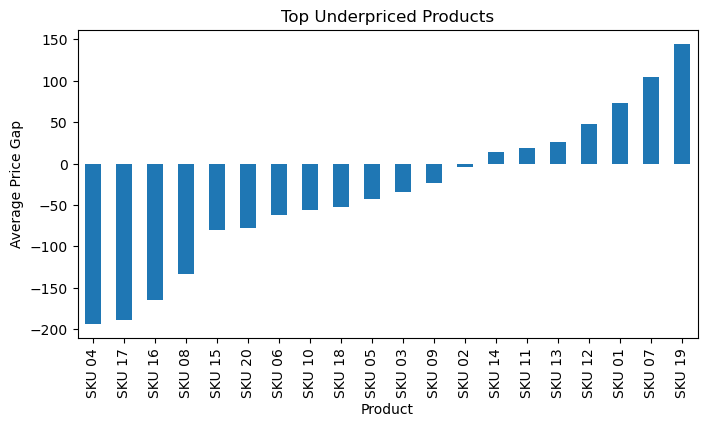

In [53]:
price_gap.plot(kind="bar", figsize=(8, 4))
plt.title("Top Underpriced Products")
plt.ylabel("Average Price Gap")

plt.show()

### insights of Competitor Analysis :

Several products are currently priced below competitor levels, particularly SKU 04, SKU 17, and SKU 16. 
These products may represent potential pricing opportunities, as the company could consider selective price increases while remaining competitively positioned in the market

On the other hand, products such as SKU 19 and SKU 07 are currently priced above competitors, indicating a need for closer monitoring to avoid potential pricing pressure or volume decline



## 4. Revenue Analysis

In [54]:
product_revenue = (
    df.groupby("Product")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue

Product
SKU 10    6512771348
SKU 16    6288503227
SKU 15    6252727646
SKU 07    6134690487
SKU 03    6134233052
SKU 19    4701310129
SKU 08    4176435904
SKU 18    3560951419
SKU 17    3557881872
SKU 09    3419584053
SKU 01    3393829073
SKU 06    3224675111
SKU 04    2418074083
SKU 14    1949405162
SKU 05    1917554134
SKU 20    1888215495
SKU 11    1337853740
SKU 13    1321832096
SKU 02    1206997512
SKU 12    1199016518
Name: Revenue, dtype: int64

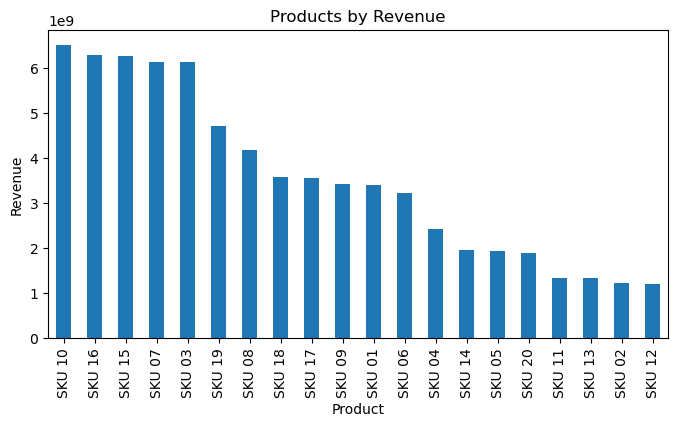

In [ ]:
product_revenue.plot(kind="bar", figsize=(8, 4))
plt.title("Products by Revenue")
plt.ylabel("Revenue")

plt.show()

### insights of Revenue Analysis :

SKU 10, SKU 16, and SKU 15 are the largest contributors to total company revenue, indicating that pricing decisions on these products could significantly impact overall business performance

Among the top revenue generating products, SKU 16 and SKU 15 remain priced below competitor levels based on previous competitor price analysis. This suggests potential opportunities for selective price increases while maintaining competitive market positioning

Conversely, certain high-revenue products such as SKU 07 are already priced above competitors, requiring more cautious pricing adjustments to minimize potential volume risk



## 5. Margin Analysis

In [70]:
product_margin = (
    df.groupby("Product")
    .agg({
        "Revenue":"sum",
        "Profit":"sum"
    }))

product_margin["MarginPercent"] = (
    product_margin["Profit"]
    /
    product_margin["Revenue"]
) * 100



product_margin.sort_values("MarginPercent")

,Revenue,Profit,MarginPercent
Product,,,
SKU 04,2418074083,625989272,25.887928
SKU 13,1321832096,349273577,26.423445
SKU 17,3557881872,951192689,26.734802
SKU 02,1206997512,323908602,26.835896
SKU 05,1917554134,516290371,26.924422
SKU 18,3560951419,963515378,27.057807
SKU 19,4701310129,1274373856,27.106781
SKU 12,1199016518,325190142,27.121406
SKU 15,6252727646,1699257792,27.176264


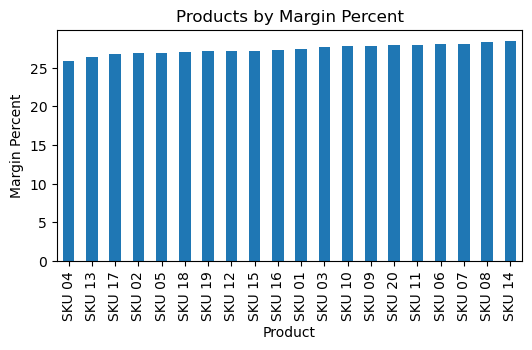

In [74]:
product_margin["MarginPercent"] \
    .sort_values() \
    .plot(kind="bar", figsize=(6,3))

plt.title("Products by Margin Percent")
plt.ylabel("Margin Percent")

plt.show()

### insights of Margin Analysis :

Margin performance across products appears relatively stable, ranging between approximately 25% and 28%. However, several high-revenue products continue to operate below average margin levels, creating opportunities for profitability improvement through pricing optimization

Products such as SKU 16 and SKU 15 are particularly important, as they combine strong revenue contribution with relatively lower margins while remaining priced below competitors based on previous competitor price analysis

These products represent strong candidates for selective price increases to improve profitability with potentially limited competitive risk

## 6. Pricing Opportunity Analysis

In [80]:
pricing_analysis = (
    df.groupby("Product")
    .agg({
        "Revenue":"sum",
        "Profit":"sum",
        "PriceGap":"mean"
    })
)

pricing_analysis["MarginPercent"] = (
    pricing_analysis["Profit"]
    /
    pricing_analysis["Revenue"]
) * 100

pricing_analysis.sort_values(
    by=["MarginPercent","Revenue"]
)


,Revenue,Profit,PriceGap,MarginPercent
Product,,,,
SKU 04,2418074083,625989272,-193.357895,25.887928
SKU 13,1321832096,349273577,25.630769,26.423445
SKU 17,3557881872,951192689,-188.741627,26.734802
SKU 02,1206997512,323908602,-4.477387,26.835896
SKU 05,1917554134,516290371,-42.203883,26.924422
SKU 18,3560951419,963515378,-52.179104,27.057807
SKU 19,4701310129,1274373856,144.594059,27.106781
SKU 12,1199016518,325190142,47.900943,27.121406
SKU 15,6252727646,1699257792,-79.546341,27.176264


### insights of Pricing Opportunity Analysis :

The analysis indicates that several products combine high revenue contribution with relatively lower margin performance while remaining priced below competitors

SKU 16 emerges as the strongest pricing opportunity due to its significant revenue contribution, below-average pricing position versus competitors, and margin improvement potential. SKU 15 also demonstrates similar characteristics, suggesting that selective price increases on these products could improve overall profitability with limited competitive risk

Meanwhile, products such as SKU 04 and SKU 17 are significantly underpriced relative to competitors but contribute lower overall revenue, indicating smaller financial impact despite pricing opportunities

Conversely, SKU 07 already operates at a price premium compared to competitors. Additional pricing adjustments on this product should therefore be approached more cautiously to minimize potential demand or volume risks

Overall, the analysis suggests that selective and targeted pricing optimization strategies could improve profitability while maintaining competitive positioning across key product categories